Setup

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## test/setup
#df_c = pd.read_csv('all_fires_full.csv')
df_p = pd.read_parquet('all_fires_full.parquet')

#print(df_c[['fire_name', 'alarm_date', 'gis_acres', 'vpd']].head())
print(df_p[['fire_name', 'alarm_date', 'gis_acres', 'vpd']].head())

  fire_name  alarm_date   gis_acres       vpd
0      10TH  2024-06-24  131.961304       NaN
1      10TH  2024-06-24  131.961304  2.155000
2      10TH  2024-06-24  131.961304  2.516667
3      10TH  2024-06-24  131.961304  2.493333
4      10TH  2024-06-24  131.961304  3.278333


Find largest fire

In [15]:
largest_fire_name = df.loc[df['gis_acres'].idxmax(), 'fire_name']
max_acres = df['gis_acres'].max()

print(f"Largest Fire: {largest_fire_name} ({max_acres:,.0f} acres)")

# filter data for this specific fire's time series
fire_ts = df[df['fire_name'] == largest_fire_name].sort_values('days_to_ignition')


Largest Fire: AUGUST COMPLEX (1,032,700 acres)


plot of vapor pressure deficit and long term drought

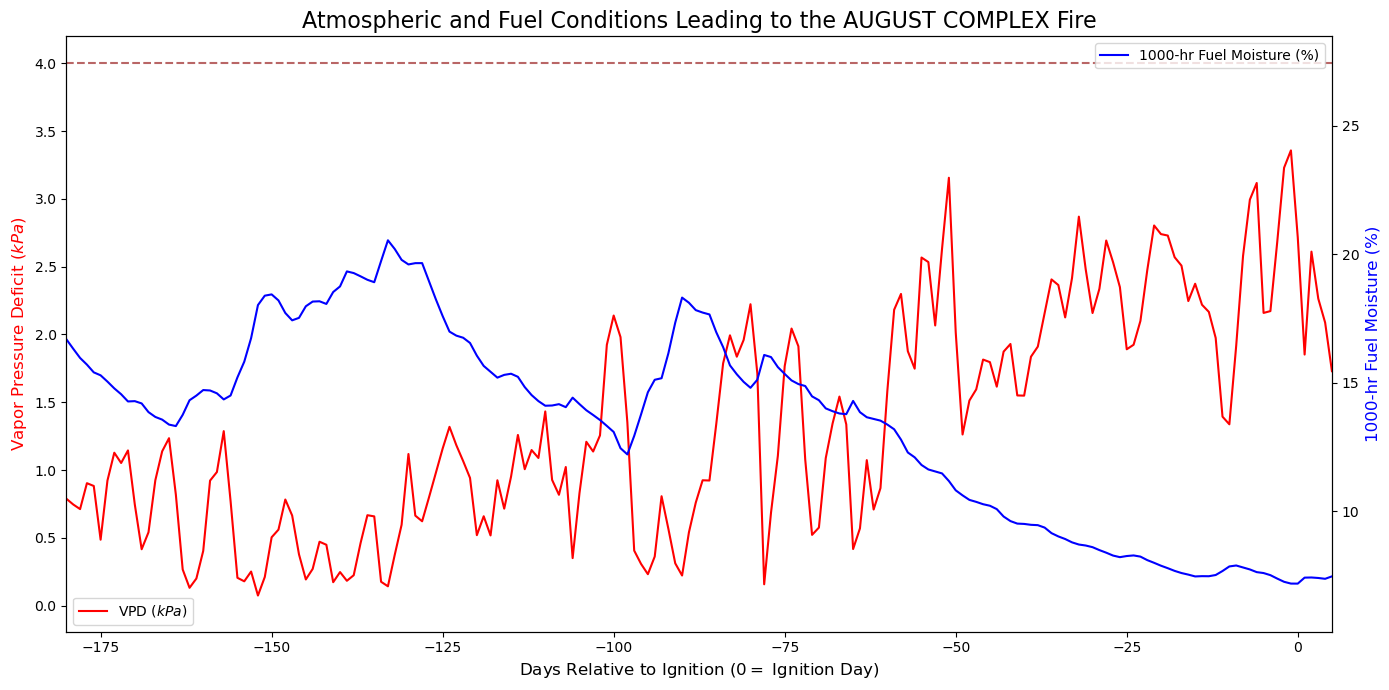

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# plot vapor pressure deficit (VPD) - strongest fire predictor
sns.lineplot(data=fire_ts, x='days_to_ignition', y='vpd', ax=ax1, color='red', label='VPD ($kPa$)')
ax1.set_ylabel('Vapor Pressure Deficit ($kPa$)', color='red', fontsize=12)
ax1.axhline(y=4, color='darkred', linestyle='--', alpha=0.6, label='Extreme Threshold (4 $kPa$)')

# second axis for fuel moisture (fm1000) - long term drought
ax2 = ax1.twinx()
sns.lineplot(data=fire_ts, x='days_to_ignition', y='fm1000', ax=ax2, color='blue', label='1000-hr Fuel Moisture (%)')
ax2.set_ylabel('1000-hr Fuel Moisture (%)', color='blue', fontsize=12)

# formatting
plt.title(f'Atmospheric and Fuel Conditions Leading to the {largest_fire_name} Fire', fontsize=16)
ax1.set_xlabel('Days Relative to Ignition ($0 = $ Ignition Day)', fontsize=12)
ax1.set_xlim(-180, 5) # focus on the 6 months leading up
fig.tight_layout()
plt.show()

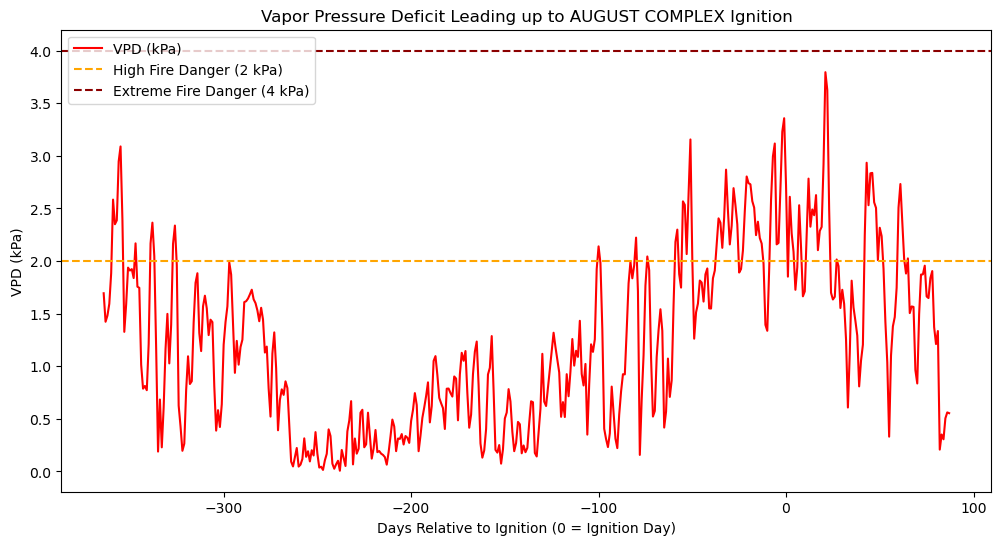

In [16]:
def plot_weather_leadup(fire_name):
    """
    Visualizes the 90-day lead up to a specific fire's ignition.
    """
    fire_data = df_p[df_p['fire_name'] == fire_name].sort_values('days_to_ignition')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=fire_data, x='days_to_ignition', y='vpd', color='red', label='VPD (kPa)')
    
    # critical thresholds as per dictionary
    plt.axhline(y=2, color='orange', linestyle='--', label='High Fire Danger (2 kPa)')
    plt.axhline(y=4, color='darkred', linestyle='--', label='Extreme Fire Danger (4 kPa)')
    
    plt.title(f'Vapor Pressure Deficit Leading up to {fire_name} Ignition')
    plt.xlabel('Days Relative to Ignition (0 = Ignition Day)')
    plt.ylabel('VPD (kPa)')
    plt.legend()
    plt.show()

# example
plot_weather_leadup('AUGUST COMPLEX')